In [1]:
import pandas as pd

df = pd.read_csv("adult23.csv")

print("DataFrame Information:")
df.info()

print("\nData Types:")
print(df.dtypes)
df.head()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29522 entries, 0 to 29521
Columns: 647 entries, URBRRL to POVRATTC_A
dtypes: float64(442), int64(204), object(1)
memory usage: 145.7+ MB

Data Types:
URBRRL           int64
RATCAT_A         int64
INCTCFLG_A       int64
IMPINCFLG_A      int64
LANGSPECR_A    float64
                ...   
RECTYPE          int64
IMPNUM_A         int64
WTFA_A         float64
HHX             object
POVRATTC_A     float64
Length: 647, dtype: object


,URBRRL,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,LANGSPECR_A,LANGSOC_A,LANGDOC_A,LANGMED_A,LANGHM_A,PPSU,...,PROXYREL_A,PROXY_A,AVAIL_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,WTFA_A,HHX,POVRATTC_A
0,3,4,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,7371.139,H029691,1.01
1,4,8,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,3146.794,H028812,2.49
2,4,14,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,10807.558,H045277,6.73
3,4,10,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,4661.643,H021192,3.43
4,4,5,0,0,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,1,1,1,10,1,10929.554,H025576,1.27


In [2]:
#Selecting chosen features for analysis

df = pd.read_csv("adult23.csv", usecols=[
    'ANXEV_A', 'AGEP_A', 'SEX_A', 'HISPALLP_A',
    ])

print(df.shape)

(29522, 4)


In [3]:
#Managing null-vales for the analysis

import numpy as np

invalid_map = {
    'ANXEV_A': [7, 8, 9],
    'AGEP_A': [7, 8, 9],
    'SEX_A': [7, 8, 9],
    'HISPALLP_A': [97, 98, 99],
}

for col, codes in invalid_map.items():
    df[col] = df[col].replace(codes, np.nan)

In [4]:
#Checking for Unique values in columns

for col in df.columns:
    print(f"\nUnique values in '{col}':")
    print(df[col].sort_values().unique())


Unique values in 'HISPALLP_A':
[1 2 3 4 5 6 7]

Unique values in 'SEX_A':
[ 1.  2. nan]

Unique values in 'AGEP_A':
[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65
 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 97 99]

Unique values in 'ANXEV_A':
[ 1.  2. nan]


In [5]:
#Turning all numbers in integer

exclude_cols = ['HISPALLP_A', 'AGEP_A']

for col in df.columns:
    if col not in exclude_cols:  
        df[col] = df[col].astype('Int64')

for col in df.columns:
    print(f"\nUnique values in '{col}':")
    print(df[col].sort_values().unique())


Unique values in 'HISPALLP_A':
[1 2 3 4 5 6 7]

Unique values in 'SEX_A':
<IntegerArray>
[1, 2, <NA>]
Length: 3, dtype: Int64

Unique values in 'AGEP_A':
[18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41
 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65
 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 97 99]

Unique values in 'ANXEV_A':
<IntegerArray>
[1, 2, <NA>]
Length: 3, dtype: Int64


In [6]:
# Checking for missing values

missing_report = df.isnull().sum()

missing_report = missing_report[missing_report > 0]

print("Columns with missing values:")
print(missing_report)

Columns with missing values:
SEX_A       6
ANXEV_A    56
dtype: int64


In [7]:
# Drop rows with missing data

df.dropna(inplace=True)

# Checking for missing values

missing_report = df.isnull().sum()

missing_report = missing_report[missing_report > 0]

print("Columns with missing values:")
print(missing_report)

Columns with missing values:
Series([], dtype: int64)


In [8]:
#Chechking for Selected Dataframe Info

print("Selected DataFrame Information:")
df.info()

Selected DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 29460 entries, 0 to 29521
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   HISPALLP_A  29460 non-null  int64
 1   SEX_A       29460 non-null  Int64
 2   AGEP_A      29460 non-null  int64
 3   ANXEV_A     29460 non-null  Int64
dtypes: Int64(2), int64(2)
memory usage: 1.2 MB


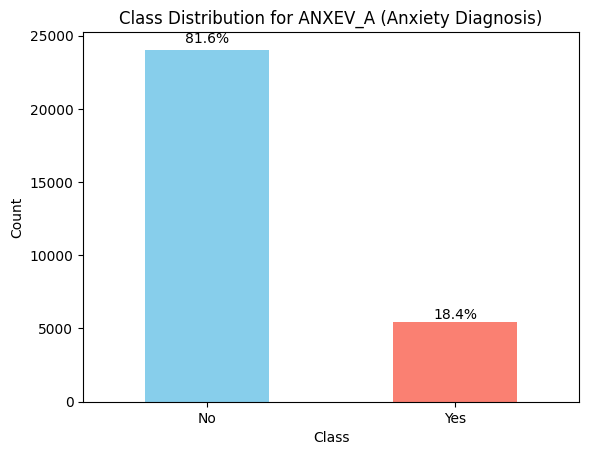

In [9]:
#Class Distribution analysis

import matplotlib.pyplot as plt
import pandas as pd

map_anxev = {1: "Yes", 2: "No"}
df['ANXEV_A'] = df['ANXEV_A'].map(map_anxev)

counts = df['ANXEV_A'].value_counts(dropna=False)
percentages = df['ANXEV_A'].value_counts(normalize=True, dropna=False) * 100

counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution for ANXEV_A (Anxiety Diagnosis)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)

for i, count in enumerate(counts):
    pct = percentages.iloc[i]
    plt.text(i, count + (count * 0.01), f"{pct:.1f}%", ha='center', va='bottom', fontsize=10)

plt.show()

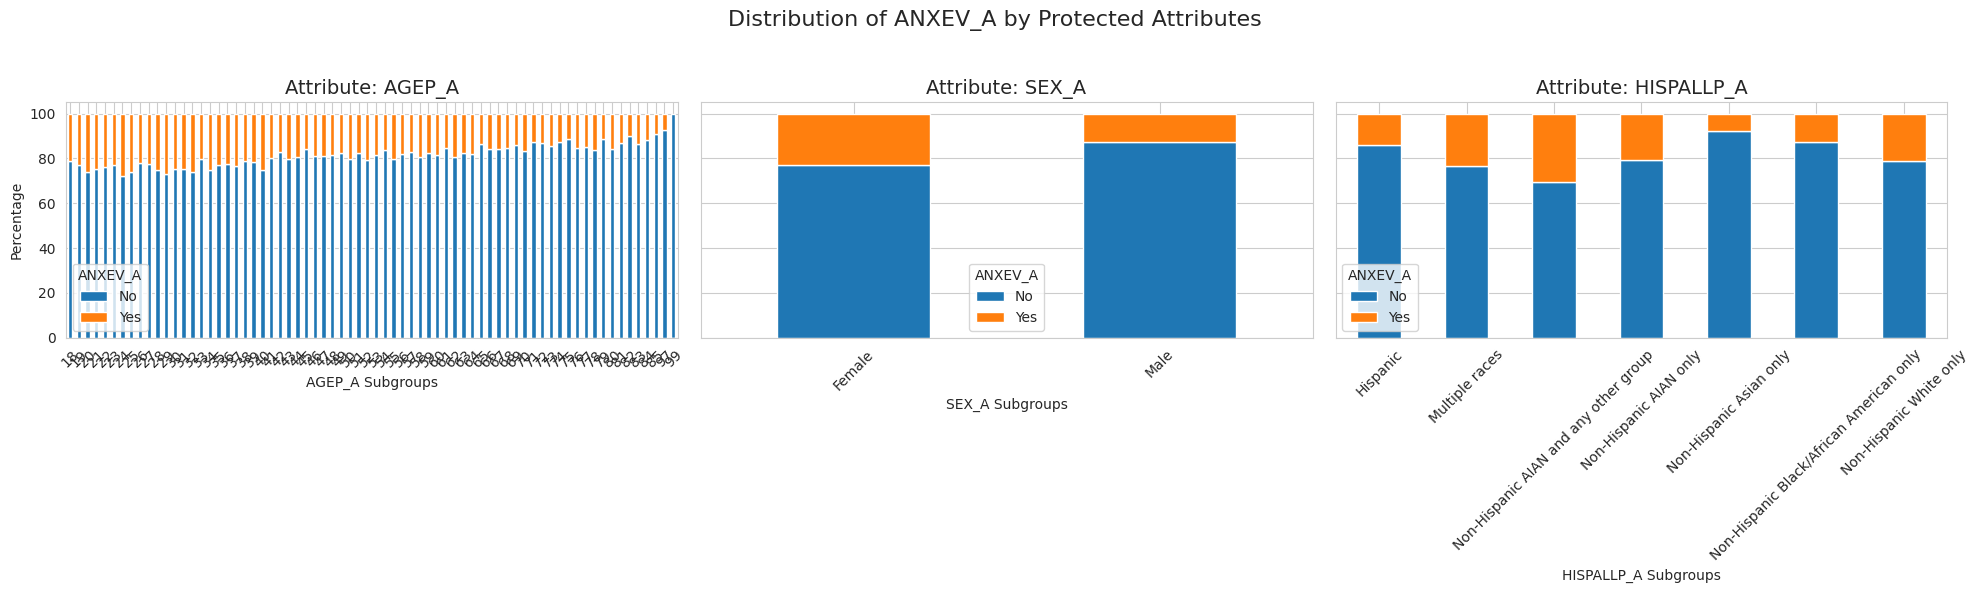

In [10]:
# Exploratory analysis of Protected Attributes

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

map_sex = {1: "Male", 2: "Female"}
map_race = {
    1: "Hispanic", 
    2: "Non-Hispanic White only",
    3: "Non-Hispanic Black/African American only", 
    4: "Non-Hispanic Asian only",
    5: "Non-Hispanic AIAN only",
    6: "Non-Hispanic AIAN and any other group",
    7: "Multiple races"
}

df['SEX_A'] = df['SEX_A'].map(map_sex)
df['HISPALLP_A'] = df['HISPALLP_A'].map(map_race)

sns.set_style("whitegrid")

protected_attributes = ['AGEP_A', 'SEX_A', 'HISPALLP_A']
target_attribute = 'ANXEV_A'

# Create a figure with a subplot for each protected attribute
fig, axes = plt.subplots(nrows=1, ncols=len(protected_attributes), figsize=(20, 6), sharey=True)
fig.suptitle(f'Distribution of {target_attribute} by Protected Attributes', fontsize=16)

# Loop through each protected attribute
for i, protected_attr in enumerate(protected_attributes):
    ax = axes[i]
    
    # Create a cross-tabulation (contingency table)
    contingency_table = pd.crosstab(df[protected_attr], df[target_attribute], normalize='index') * 100
    
    # Plot a stacked bar chart
    contingency_table.plot(kind='bar', stacked=True, ax=ax)
    
    # Set plot titles and labels
    ax.set_title(f'Attribute: {protected_attr}', fontsize=14)
    ax.set_xlabel(f'{protected_attr} Subgroups')
    ax.set_ylabel('Percentage' if i == 0 else "")
    ax.legend(title=target_attribute)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_24100/1851327277.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels([f'{int(x*100)}%' for x in vals])
/tmp/ipykernel_24100/1851327277.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_yticklabels([f'{int(x*100)}%' for x in vals])


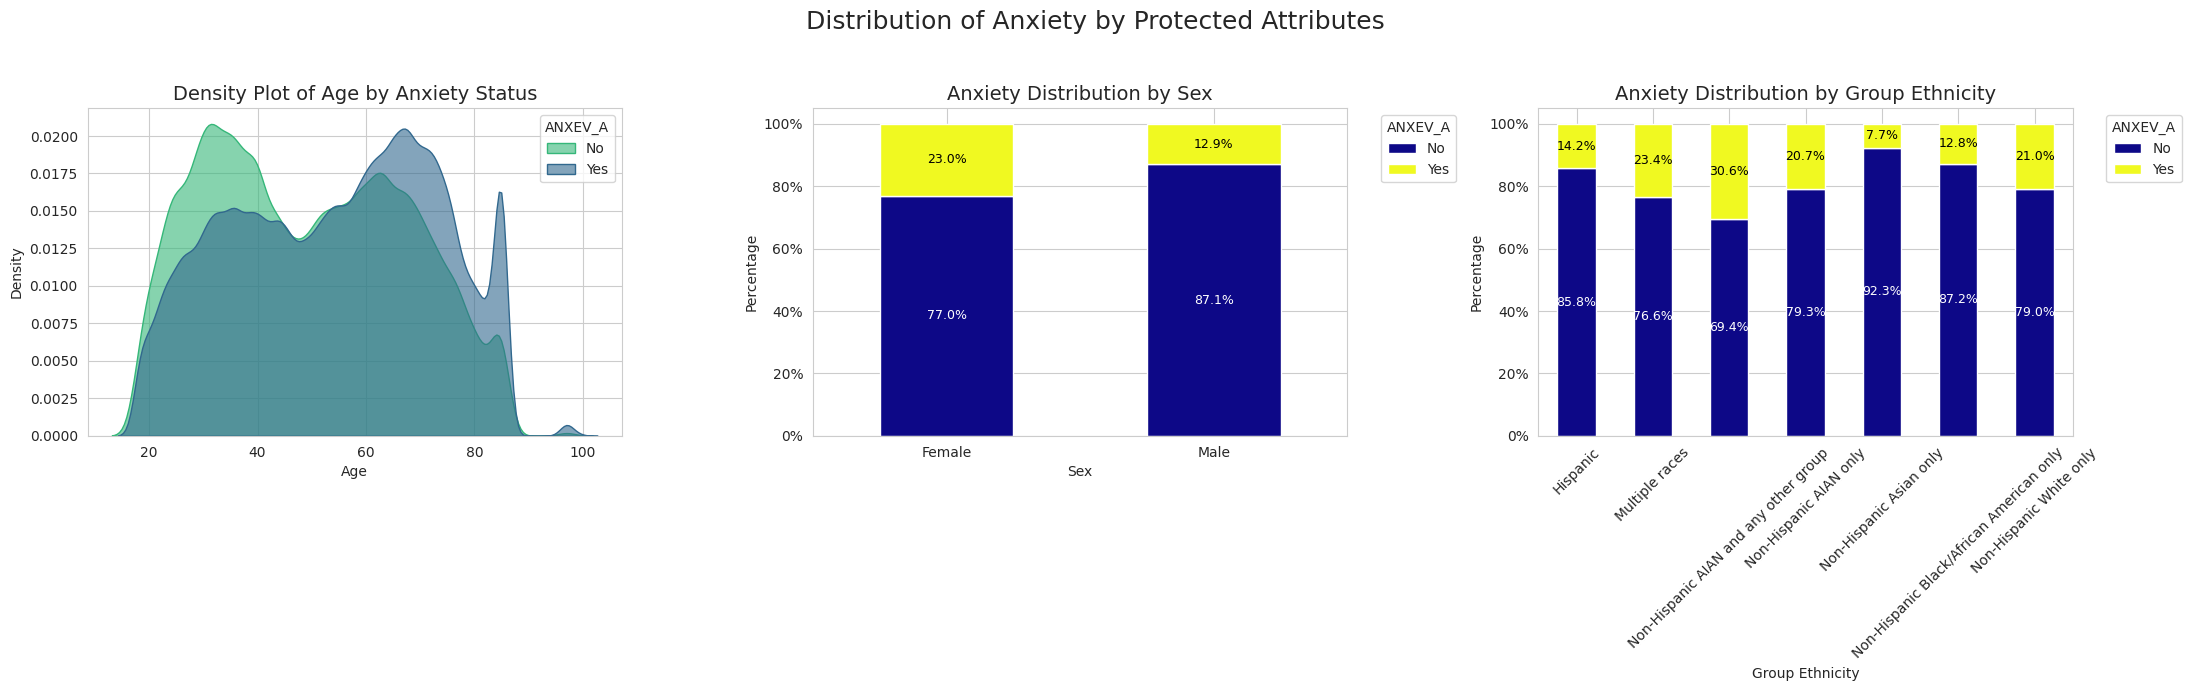

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a color palette for consistency across plots
palette = sns.color_palette("viridis", 2)

#determine the best text color based on background
def get_text_color(rgb_color):
    r, g, b, _ = rgb_color
    brightness = 0.299*r + 0.587*g + 0.114*b
    return 'white' if brightness < 0.5 else 'black'

# Create a figure with a subplot for each protected attribute
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
fig.suptitle('Distribution of Anxiety by Protected Attributes', fontsize=18)

# Density Plot for AGEP_A
sns.kdeplot(
    data=df,
    x='AGEP_A',
    hue='ANXEV_A',
    fill=True,
    ax=axes[0],
    palette=palette,
    common_norm=False,
    alpha=0.6,
    bw_adjust=0.5
)
axes[0].set_title('Density Plot of Age by Anxiety Status', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend(title='ANXEV_A', labels=df['ANXEV_A'].unique())

#Stacked Bar Chart for SEX_A 
contingency_table_sex = pd.crosstab(df['SEX_A'], df['ANXEV_A'], normalize='index')
contingency_table_sex.plot(kind='bar', stacked=True, ax=axes[1], cmap='plasma')
axes[1].set_title('Anxiety Distribution by Sex', fontsize=14)
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='ANXEV_A', labels=df['ANXEV_A'].unique(), bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

# Format y-axis ticks to show percentages
vals = axes[1].get_yticks()
axes[1].set_yticklabels([f'{int(x*100)}%' for x in vals])

# Add text labels on the bars
for container in axes[1].containers:
    text_color = 'white' if i == 0 else 'black'
    for bar in container:
        height = bar.get_height()
        if height > 0.01:
            color = get_text_color(bar.get_facecolor())
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_y() + height / 2,
                         f'{height:.1%}',
                         ha='center', va='center', fontsize=9, color=color)

# Stacked Bar Chart for HISPALLP_A 
contingency_table_hisp = pd.crosstab(df['HISPALLP_A'], df['ANXEV_A'], normalize='index')
contingency_table_hisp.plot(kind='bar', stacked=True, ax=axes[2], cmap='plasma')
axes[2].set_title('Anxiety Distribution by Group Ethnicity', fontsize=14)
axes[2].set_xlabel('Group Ethnicity')
axes[2].set_ylabel('Percentage')
axes[2].legend(title='ANXEV_A', labels=df['ANXEV_A'].unique(), bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].tick_params(axis='x', rotation=45)

# Format y-axis ticks to show percentages
vals = axes[2].get_yticks()
axes[2].set_yticklabels([f'{int(x*100)}%' for x in vals])

# Add text labels on the bars
for container in axes[2].containers:
    text_color = 'white' if i == 0 else 'black'
    for bar in container:
        height = bar.get_height()
        if height > 0.01:
            color = get_text_color(bar.get_facecolor())
            axes[2].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_y() + height / 2,
                         f'{height:.1%}',
                         ha='center', va='center', fontsize=9, color=color)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [27]:
df.to_csv("SelectedClean_nhis2023.csv", index=False)

In [13]:
!pip install aif360

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 1.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 1.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 2.0 MB/s eta 0:00:00a 0:00:01


In [15]:
!pip install aif360[AdversarialDebiasing]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.4 MB/s eta 0:00:0000:0100:09
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 1.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 1.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 1.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 874.6 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.5 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 1.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 1.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319

In [16]:
!pip install aif360[Reductions]
!pip install aif360[inFairness]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 1.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.7/901.7 kB 2.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.5 MB/s eta 0:00:0000:0100:11m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.5 MB/s eta 0:00:0000:0100:07
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 2.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 2.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 642.1/706.8 MB 573.8 kB/s eta 0:01:53
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.

In [7]:
#Loading Cleaned Data and turning attributes into numeric

import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

df['ANXEV_A'] = df['ANXEV_A'].map({'Yes': 1, 'No': 0}).astype(int)
df['SEX_A'] = df['SEX_A'].map({'Male': 1, 'Female': 0}).astype(int)
df['HISPALLP_A'] = df['HISPALLP_A'].map({
    'Hispanic': 1,
    'Non-Hispanic White only': 2,
    'Non-Hispanic Black/African American only': 3,
    'Non-Hispanic Asian only': 4,
    'Non-Hispanic AIAN only': 5,
    'Non-Hispanic AIAN and any other group': 6,
    'Multiple races': 7
}).astype(int)

df_aif = df.copy()

print(df_aif.head())

   HISPALLP_A  SEX_A  AGEP_A  ANXEV_A
0           3      1      67        0
1           2      1      73        0
2           3      1      48        0
3           2      0      42        0
4           2      0      50        0


In [23]:
#Reweighing protected attributes

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

def safe_reweighing(df, label_attr, protected_attr, fav_label=1, unfav_label=0):
    print(f"\nChecking {protected_attr} for empty groups...")
    cross_tab = pd.crosstab(df[protected_attr], df[label_attr])
    print(cross_tab)

    # Remove categories that lack representation
    valid_categories = cross_tab[(cross_tab[fav_label] > 0) & (cross_tab[unfav_label] > 0)].index.tolist()
    df = df[df[protected_attr].isin(valid_categories)]

    dataset_orig = BinaryLabelDataset(
        favorable_label=fav_label,
        unfavorable_label=unfav_label,
        df=df[[label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )

    RW = Reweighing(unprivileged_groups=[{protected_attr: valid_categories[0]}],
                    privileged_groups=[{protected_attr: valid_categories[1]}])
    dataset_transf = RW.fit_transform(dataset_orig)

    df_balanced, _ = dataset_transf.convert_to_dataframe()
    df_balanced["instance_weight"] = dataset_transf.instance_weights
    
    print(f"Finished reweighing for {protected_attr}")
    return dataset_transf, df_balanced


    # Run reweighing 
ds_sex_balanced, df_sex_balanced = safe_reweighing(df_aif, "ANXEV_A", "SEX_A")
ds_hisp_balanced, df_hisp_balanced = safe_reweighing(df_aif, "ANXEV_A", "HISPALLP_A")


Checking SEX_A for empty groups...
ANXEV_A      0     1
SEX_A               
0        12342  3691
1        11692  1735
Finished reweighing for SEX_A

Checking HISPALLP_A for empty groups...
ANXEV_A         0     1
HISPALLP_A             
1            3788   627
2           15373  4080
3            2794   411
4            1534   128
5             153    40
6             150    66
7             242    74
Finished reweighing for HISPALLP_A


In [24]:
print(df_sex_balanced.head())
print(df_hisp_balanced.head())


   SEX_A  ANXEV_A  instance_weight
0    1.0      0.0         0.936879
1    1.0      0.0         0.936879
2    1.0      0.0         0.936879
3    0.0      0.0         1.059797
4    0.0      0.0         1.059797
   HISPALLP_A  ANXEV_A  instance_weight
0         3.0      0.0         1.000000
1         2.0      0.0         1.032336
2         3.0      0.0         1.000000
3         2.0      0.0         1.032336
4         2.0      0.0         1.032336


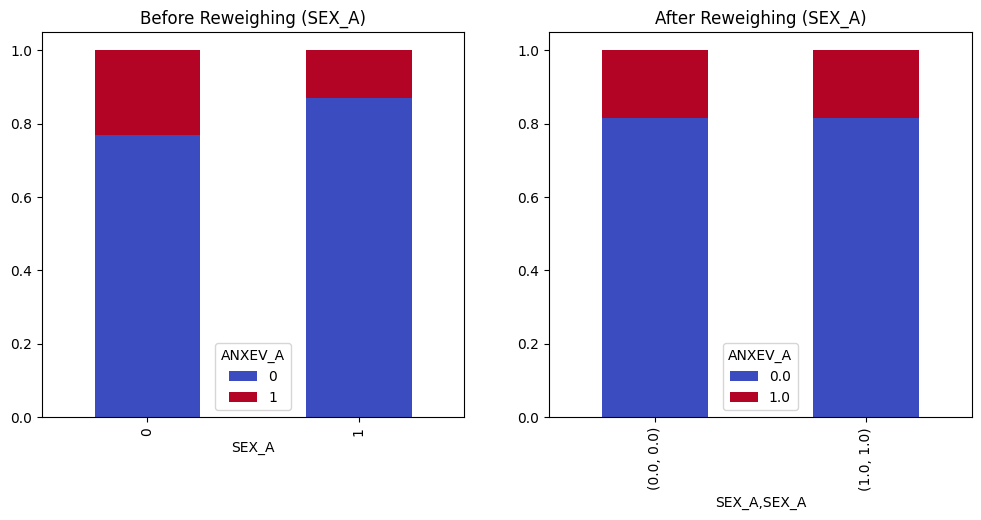

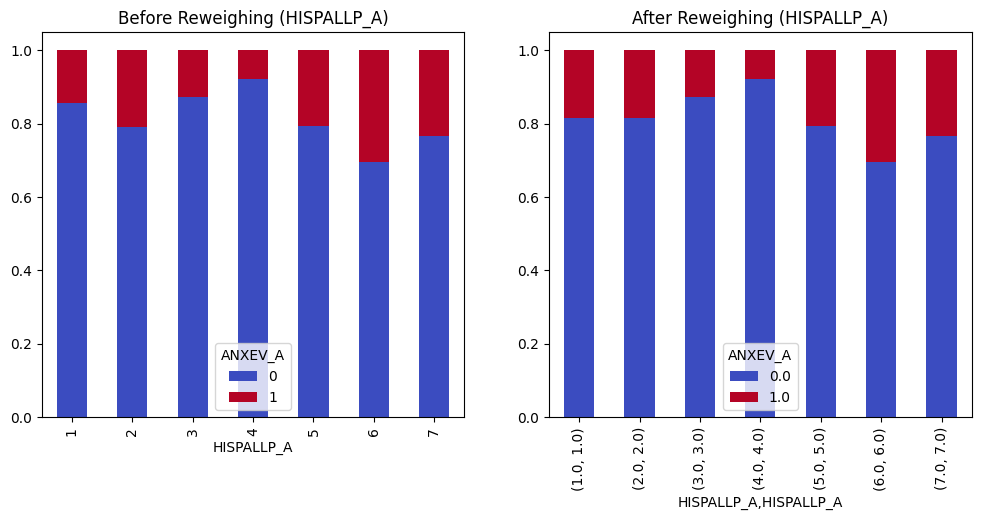

In [27]:
#Compare before vs. after reweighing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def compare_before_after(original_df, balanced_ds, target, protected):
    before = pd.crosstab(original_df[protected], original_df[target], normalize="index")

    df_balanced, _ = balanced_ds.convert_to_dataframe()
    weights = balanced_ds.instance_weights
    
    after = (
        df_balanced
        .assign(weights=weights)
        .groupby([protected, target])['weights']
        .sum()
        .groupby(level=0)
        .apply(lambda x: x / x.sum())
        .unstack(fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    before.plot(kind="bar", stacked=True, ax=axes[0], colormap="coolwarm")
    axes[0].set_title(f"Before Reweighing ({protected})")
    after.plot(kind="bar", stacked=True, ax=axes[1], colormap="coolwarm")
    axes[1].set_title(f"After Reweighing ({protected})")
    plt.show()

   # Compare visualizations
compare_before_after(df_aif, ds_sex_balanced, "ANXEV_A", "SEX_A")
compare_before_after(df_aif, ds_hisp_balanced, "ANXEV_A", "HISPALLP_A")

In [33]:
#Re-doing mapping to make HISPALLP_A binary

import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

df['ANXEV_A'] = df['ANXEV_A'].map({'Yes': 1, 'No': 0}).astype(int)
df['SEX_A'] = df['SEX_A'].map({'Male': 0, 'Female': 1}).astype(int)
df['HISPALLP_BIN'] = df['HISPALLP_A'].map({
    'Non-Hispanic White only': 1,  
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}).astype(int)

df_aif = df.copy()

print(df_aif.head())

                                 HISPALLP_A  SEX_A  AGEP_A  ANXEV_A  \
0  Non-Hispanic Black/African American only      0      67        0   
1                   Non-Hispanic White only      0      73        0   
2  Non-Hispanic Black/African American only      0      48        0   
3                   Non-Hispanic White only      1      42        0   
4                   Non-Hispanic White only      1      50        0   

   HISPALLP_BIN  
0             0  
1             1  
2             0  
3             1  
4             1  


In [34]:
#Reweighing protected attributes

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

def safe_reweighing(df, label_attr, protected_attr, fav_label=1, unfav_label=0):
    print(f"\nChecking {protected_attr} for empty groups...")
    cross_tab = pd.crosstab(df[protected_attr], df[label_attr])
    print(cross_tab)

    # Remove categories that lack representation
    valid_categories = cross_tab[(cross_tab[fav_label] > 0) & (cross_tab[unfav_label] > 0)].index.tolist()
    df = df[df[protected_attr].isin(valid_categories)]

    dataset_orig = BinaryLabelDataset(
        favorable_label=fav_label,
        unfavorable_label=unfav_label,
        df=df[[label_attr, protected_attr]],
        label_names=[label_attr],
        protected_attribute_names=[protected_attr]
    )

    RW = Reweighing(unprivileged_groups=[{protected_attr: valid_categories[0]}],
                    privileged_groups=[{protected_attr: valid_categories[1]}])
    dataset_transf = RW.fit_transform(dataset_orig)

    df_balanced, _ = dataset_transf.convert_to_dataframe()
    df_balanced["instance_weight"] = dataset_transf.instance_weights
    
    print(f"Finished reweighing for {protected_attr}")
    return dataset_transf, df_balanced


    # Run reweighing 
ds_sex_balanced, df_sex_balanced = safe_reweighing(df_aif, "ANXEV_A", "SEX_A")
ds_hisp_balanced, df_hisp_balanced = safe_reweighing(df_aif, "ANXEV_A", "HISPALLP_BIN")


Checking SEX_A for empty groups...
ANXEV_A      0     1
SEX_A               
0        11692  1735
1        12342  3691
Finished reweighing for SEX_A

Checking HISPALLP_BIN for empty groups...
ANXEV_A           0     1
HISPALLP_BIN             
0              8661  1346
1             15373  4080
Finished reweighing for HISPALLP_BIN


In [31]:
print(df_sex_balanced.head())
print(df_hisp_balanced.head())

   SEX_A  ANXEV_A  instance_weight
0    0.0      0.0         0.936879
1    0.0      0.0         0.936879
2    0.0      0.0         0.936879
3    1.0      0.0         1.059797
4    1.0      0.0         1.059797
   HISPALLP_BIN  ANXEV_A  instance_weight
0           1.0      0.0         0.942604
1           0.0      0.0         1.032336
2           1.0      0.0         0.942604
3           0.0      0.0         1.032336
4           0.0      0.0         1.032336


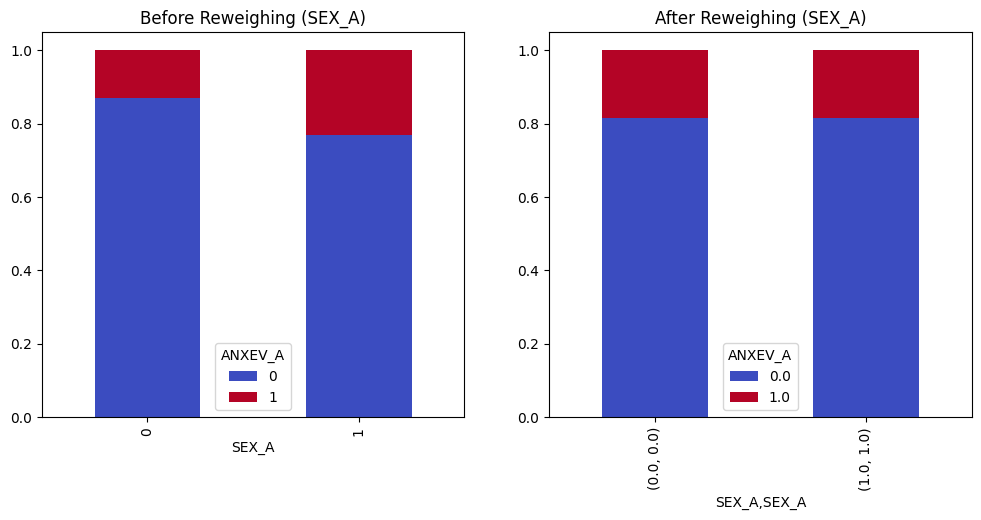

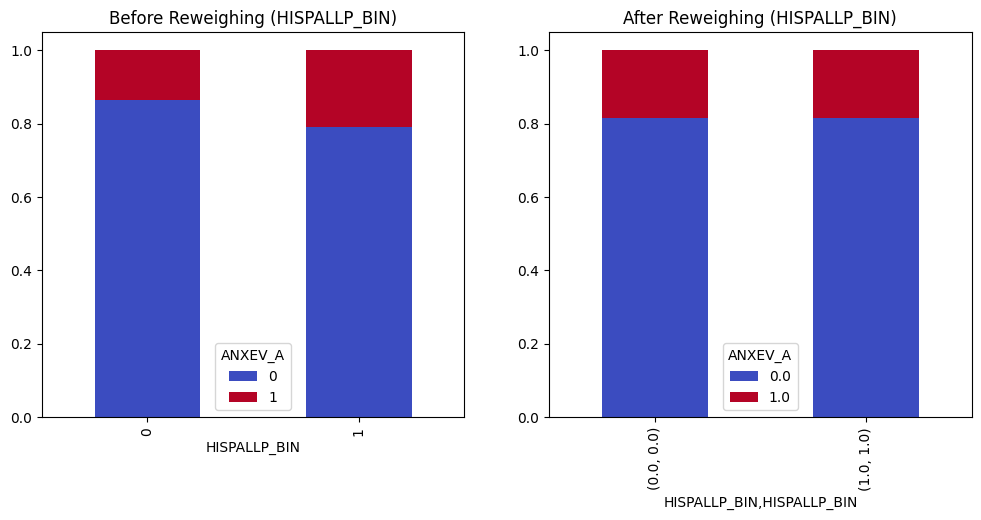

In [35]:
#Compare before vs. after reweighing with HISPALLP_BIN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def compare_before_after(original_df, balanced_ds, target, protected):
    before = pd.crosstab(original_df[protected], original_df[target], normalize="index")

    df_balanced, _ = balanced_ds.convert_to_dataframe()
    weights = balanced_ds.instance_weights
    
    after = (
        df_balanced
        .assign(weights=weights)
        .groupby([protected, target])['weights']
        .sum()
        .groupby(level=0)
        .apply(lambda x: x / x.sum())
        .unstack(fill_value=0)
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    before.plot(kind="bar", stacked=True, ax=axes[0], colormap="coolwarm")
    axes[0].set_title(f"Before Reweighing ({protected})")
    after.plot(kind="bar", stacked=True, ax=axes[1], colormap="coolwarm")
    axes[1].set_title(f"After Reweighing ({protected})")
    plt.show()

   # Compare visualizations
compare_before_after(df_aif, ds_sex_balanced, "ANXEV_A", "SEX_A")
compare_before_after(df_aif, ds_hisp_balanced, "ANXEV_A", "HISPALLP_BIN")